# 🏙️ Vancouver Off Campus Housing Rent Prediction Project

## ❓ Problem Statement

Vancouver’s rental market has become increasingly unaffordable, especially for students, newcomers, and low-to-middle income families. Average rents vary significantly across neighborhoods and room types, and are rapidly increasing each year. However, there is limited publicly accessible analysis that helps renters **predict future rent trends** or understand **which combinations of room type and zone offer better value**.

This project aims to fill that gap by analyzing historical rental data (2020–2024) and using predictive models to estimate future rental costs across Vancouver. The goal is to help renters make **informed housing decisions** based on reliable, data-driven insights.

---

## 📊 Data Source

Data was collected from the **CMHC (Canada Mortgage and Housing Corporation) Housing Market Information Portal**:  
🔗 [CMHC Rental Data](https://www03.cmhc-schl.gc.ca/hmip-pimh/en/TableMapChart/Table?TableId=2.1.31.3&GeographyId=2410&GeographyTypeId=3&DisplayAs=Table&GeograghyName=Vancouver#3%20Bedroom%20+)

- **Region**: Vancouver  
- **Years Covered**: 2020–2024  
- **Room Types**: Bachelor, 1BHK, 2BHK, 3BHK  
---

## 🎯 Project Objectives


- Analyze rent **growth patterns** from 2020 to 2024 by room type and neighborhood  
- Visualize trends in **average rent** across time, zones, and unit types  
- Build predictive models using features such as **year**, **room type**, and **zone**  
- Compare performance of multiple models:
  - Linear Regression  
  - Decision Tree  
  - Random Forest  
  - XGBoost  
- Evaluate models using metrics like **RMSE (Root Mean Squared Error)** and **MAE (Mean Absolute Error)**  
- Select the **best-performing model** for future rent prediction  
- Forecast **future rental prices** (e.g., for the year 2025) using the best model  
- Develop a **user-defined function** to make future rent predictions dynamically  
- Provide insights on **value-for-money across neighborhoods**  
- Visualize and interpret **model outputs** and **comparisons** through plots  

---
## ⏳ Efforts & Challenges

- Manually cleaned and merged datasets spanning multiple years and room types  
- Handled missing and inconsistent records to ensure data quality and reliability  
- Experimented with various machine learning models and hyperparameters to optimize performance  
- Iteratively tested and compared models to select the one with the **highest predictive accuracy**  


In [1]:
library(tidyverse)
library(ggplot2)
install.packages("rsample")
library(rsample)
install.packages("Metrics")
library(Metrics)
install.packages("rpart")
install.packages("rpart.plot")
library(rpart)
library(rpart.plot)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



## 🧼 Data Cleaning and Preparation

We loaded and cleaned rental housing datasets for **Bachelor**, **1BHK**, **2BHK**, and **3BHK** units across the years 2020 to 2024. The cleaning steps included:

- **Loading CSV files** for each unit type and year.
- **Removing unnecessary columns**: `availability_rate` and `vacancy_rate`.
- **Filtering out rows with missing values** in `average_rent` and `median_rent`.

This process ensures that the data used for analysis is clean, consistent, and complete.


In [2]:
# Bachelor
housing_Bachelor_2020 <- read_csv("Data/Cleaned_Housing_Rental_Data/Bachelor_2020_clean.csv", show_col_types = FALSE) |> select(-availability_rate,-vacancy_rate)|>filter(!is.na(average_rent),!is.na(median_rent))
housing_Bachelor_2021 <- read_csv("Data/Cleaned_Housing_Rental_Data/Bachelor_2021_clean.csv", show_col_types = FALSE) |> select(-availability_rate,-vacancy_rate)|>filter(!is.na(average_rent),!is.na(median_rent))
housing_Bachelor_2022 <- read_csv("Data/Cleaned_Housing_Rental_Data/Bachelor_2022_clean.csv", show_col_types = FALSE) |> select(-availability_rate,-vacancy_rate)|>filter(!is.na(average_rent),!is.na(median_rent))
housing_Bachelor_2023 <- read_csv("Data/Cleaned_Housing_Rental_Data/Bachelor_2023_clean.csv", show_col_types = FALSE) |> select(-availability_rate,-vacancy_rate)|>filter(!is.na(average_rent),!is.na(median_rent))
housing_Bachelor_2024 <- read_csv("Data/Cleaned_Housing_Rental_Data/Bachelor_2024_clean.csv", show_col_types = FALSE) |> select(-availability_rate,-vacancy_rate)|>filter(!is.na(average_rent),!is.na(median_rent))

# 1BHK
housing_1BHK_2020 <- read_csv("Data/Cleaned_Housing_Rental_Data/1BHK_2020_clean.csv", show_col_types = FALSE) |> select(-availability_rate,-vacancy_rate)|>filter(!is.na(average_rent),!is.na(median_rent))
housing_1BHK_2021 <- read_csv("Data/Cleaned_Housing_Rental_Data/1BHK_2021_clean.csv", show_col_types = FALSE) |> select(-availability_rate,-vacancy_rate)|>filter(!is.na(average_rent),!is.na(median_rent))
housing_1BHK_2022 <- read_csv("Data/Cleaned_Housing_Rental_Data/1BHK_2022_clean.csv", show_col_types = FALSE) |> select(-availability_rate,-vacancy_rate)|>filter(!is.na(average_rent),!is.na(median_rent))
housing_1BHK_2023 <- read_csv("Data/Cleaned_Housing_Rental_Data/1BHK_2023_clean.csv", show_col_types = FALSE) |> select(-availability_rate,-vacancy_rate)|>filter(!is.na(average_rent),!is.na(median_rent))
housing_1BHK_2024 <- read_csv("Data/Cleaned_Housing_Rental_Data/1BHK_2024_clean.csv", show_col_types = FALSE) |> select(-availability_rate,-vacancy_rate)|>filter(!is.na(average_rent),!is.na(median_rent))

# 2BHK
housing_2BHK_2020 <- read_csv("Data/Cleaned_Housing_Rental_Data/2BHK_2020_clean.csv", show_col_types = FALSE) |> select(-availability_rate,-vacancy_rate)|>filter(!is.na(average_rent),!is.na(median_rent))
housing_2BHK_2021 <- read_csv("Data/Cleaned_Housing_Rental_Data/2BHK_2021_clean.csv", show_col_types = FALSE) |> select(-availability_rate,-vacancy_rate)|>filter(!is.na(average_rent),!is.na(median_rent))
housing_2BHK_2022 <- read_csv("Data/Cleaned_Housing_Rental_Data/2BHK_2022_clean.csv", show_col_types = FALSE) |> select(-availability_rate,-vacancy_rate)|>filter(!is.na(average_rent),!is.na(median_rent))
housing_2BHK_2023 <- read_csv("Data/Cleaned_Housing_Rental_Data/2BHK_2023_clean.csv", show_col_types = FALSE) |> select(-availability_rate,-vacancy_rate)|>filter(!is.na(average_rent),!is.na(median_rent))
housing_2BHK_2024 <- read_csv("Data/Cleaned_Housing_Rental_Data/2BHK_2024_clean.csv", show_col_types = FALSE) |> select(-availability_rate,-vacancy_rate)|>filter(!is.na(average_rent),!is.na(median_rent))

# 3BHK
housing_3BHK_2020 <- read_csv("Data/Cleaned_Housing_Rental_Data/3BHK_2020_clean.csv", show_col_types = FALSE) |> select(-availability_rate,-vacancy_rate)|>filter(!is.na(average_rent),!is.na(median_rent))
housing_3BHK_2021 <- read_csv("Data/Cleaned_Housing_Rental_Data/3BHK_2021_clean.csv", show_col_types = FALSE) |> select(-availability_rate,-vacancy_rate)|>filter(!is.na(average_rent),!is.na(median_rent))
housing_3BHK_2022 <- read_csv("Data/Cleaned_Housing_Rental_Data/3BHK_2022_clean.csv", show_col_types = FALSE) |> select(-availability_rate,-vacancy_rate)|>filter(!is.na(average_rent),!is.na(median_rent))
housing_3BHK_2023 <- read_csv("Data/Cleaned_Housing_Rental_Data/3BHK_2023_clean.csv", show_col_types = FALSE) |> select(-availability_rate,-vacancy_rate)|>filter(!is.na(average_rent),!is.na(median_rent))
housing_3BHK_2024 <- read_csv("Data/Cleaned_Housing_Rental_Data/3BHK_2024_clean.csv", show_col_types = FALSE) |> select(-availability_rate,-vacancy_rate)|>filter(!is.na(average_rent),!is.na(median_rent))


## 🧩 Combining Datasets

Merged all cleaned datasets across years and unit types into a single dataframe `housing_all` using `bind_rows()`.


In [3]:
housing_all <- bind_rows(
  housing_Bachelor_2020, housing_Bachelor_2021, housing_Bachelor_2022, housing_Bachelor_2023, housing_Bachelor_2024,
  housing_1BHK_2020, housing_1BHK_2021, housing_1BHK_2022, housing_1BHK_2023, housing_1BHK_2024,
  housing_2BHK_2020, housing_2BHK_2021, housing_2BHK_2022, housing_2BHK_2023, housing_2BHK_2024,
  housing_3BHK_2020, housing_3BHK_2021, housing_3BHK_2022, housing_3BHK_2023, housing_3BHK_2024
)

## 📊 Summary Statistics

Descriptive summary of `housing_all` containing data from 2020–2024


In [25]:
summary(housing_all)

      year       room_type             zone            average_rent 
 Min.   :2020   Length:384         Length:384         Min.   : 713  
 1st Qu.:2021   Class :character   Class :character   1st Qu.:1336  
 Median :2022   Mode  :character   Mode  :character   Median :1624  
 Mean   :2022                                         Mean   :1796  
 3rd Qu.:2023                                         3rd Qu.:2060  
 Max.   :2024                                         Max.   :4814  
  median_rent       units     
 Min.   : 750   Min.   :  11  
 1st Qu.:1300   1st Qu.: 270  
 Median :1608   Median : 849  
 Mean   :1762   Mean   :1370  
 3rd Qu.:2000   3rd Qu.:1732  
 Max.   :4800   Max.   :7974  

## 📈 Average Rent Trends by Room Type

Line plot showing the mean average rent from the year 2020 to 2024 for each room type.


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


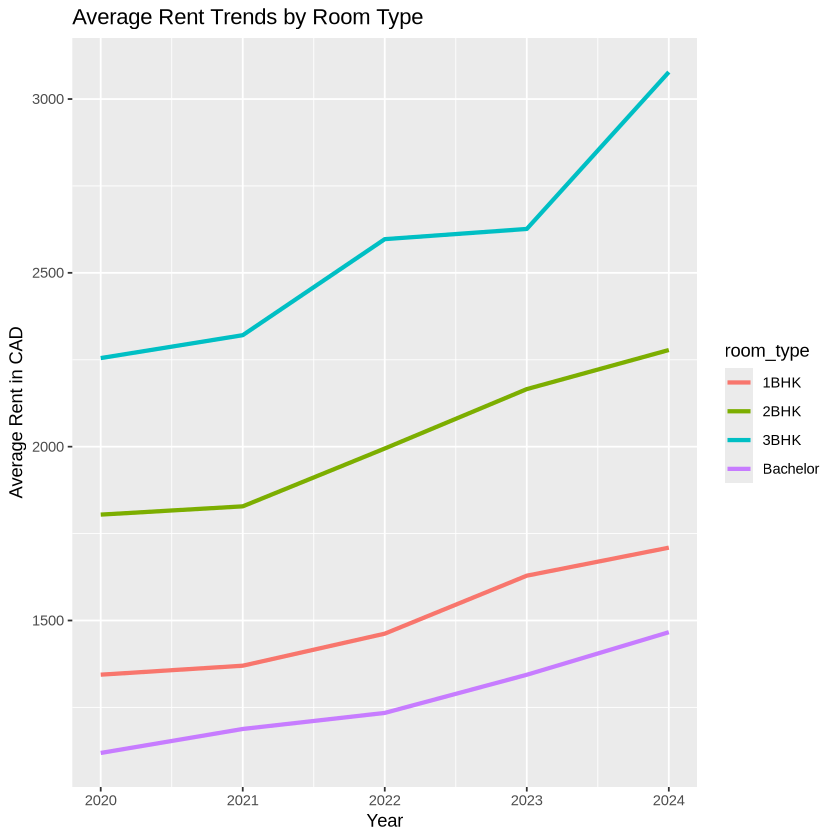

In [5]:
ggplot(housing_all, aes(x = year, y = average_rent, color = room_type)) +
  stat_summary(fun = mean, geom = "line", size = 1.2) +
  labs(title = "Average Rent Trends by Room Type",x= "Year", y = "Average Rent in CAD")

## 📊 Analysis of Average Rent Trends by Room Type (2020–2024)

This line plot illustrates how the **average rent** (y-axis, in CAD) has changed over the years **2020 to 2024** (x-axis) for each **room type** (color-coded).

### Key Observations
- **3-BHK units** consistently have the **highest average rent**, rising sharply from **≈ \$2,250** in 2020 to **more than \$3,000** in 2024.  
- **2-BHK units** also show a steady increase, climbing from **\$1,800** to **\$2,300** over the five years.  
- **1-BHK units** start around **\$1,350** in 2020 and reach nearly **\$1,750** by 2024, indicating moderate growth.  
- **Bachelor units** have the **lowest average rent**, yet still exhibit an upward trend—from **\$1,100** to roughly **\$1,470**.

### Conclusion
There is a **consistent upward trend** in rental prices across all unit types. Larger units display **steeper increases**, reflecting growing demand or a constrained supply in higher-capacity housing.

---
---

## 📊 Data Splitting: Training and Testing Sets

To ensure our model can generalize well, we split the cleaned housing dataset into training and testing sets using an 80-20 ratio. We stratify by `room_type` to maintain proportional representation of each room type in both sets.

In [6]:
set.seed(1000)
housing_split<-initial_split(housing_all,prop=0.8,strata= room_type)
housing_train <- training(housing_split)
housing_test  <- testing(housing_split)

### 📈 Linear Regression Model

We fit a linear regression model to predict `average_rent` based on `year`, `room_type`, and `zone` using the training data.

In [7]:
housing_model_lm <- lm(average_rent ~ year + room_type + zone, data = housing_train)
summary(housing_model_lm)


Call:
lm(formula = average_rent ~ year + room_type + zone, data = housing_train)

Residuals:
   Min     1Q Median     3Q    Max 
-688.0 -156.1  -15.7  148.1 1092.5 

Coefficients:
                                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)                        -2.201e+05  2.142e+04 -10.275  < 2e-16 ***
year                                1.095e+02  1.059e+01  10.338  < 2e-16 ***
room_type2BHK                       5.141e+02  3.925e+01  13.098  < 2e-16 ***
room_type3BHK                       1.124e+03  4.303e+01  26.115  < 2e-16 ***
room_typeBachelor                  -2.461e+02  4.031e+01  -6.105 3.41e-09 ***
zoneDelta                          -1.145e+02  8.810e+01  -1.300 0.194794    
zoneDowntown                        8.614e+02  8.959e+01   9.615  < 2e-16 ***
zoneEast Hastings                   3.333e+01  8.677e+01   0.384 0.701185    
zoneEnglish Bay                     5.006e+02  9.585e+01   5.223 3.43e-07 ***
zoneKitsilano/Point Grey            5.4

### 📘 Understanding the Linear Regression Model

This linear regression model predicts **average rent** using the following variables:

- `year` — the year of observation (numerical)
- `room_type` — type of unit (categorical: 1BHK, 2BHK, 3BHK, Bachelor)
- `zone` — the geographic area or neighborhood (categorical)

---

### 🔢 What Are Dummy Variables?

Since regression models work with numbers, categorical variables like `room_type` and `zone` are automatically converted into **dummy variables** 

For example, if `room_type` has four categories: `1BHK`, `2BHK`, `3BHK`, `Bachelor`, the model creates dummy variables for three of them:

- `2BHK`
- `3BHK`
- `Bachelor`

The **category left out** (`1BHK`) becomes the **reference category**. If all dummy variables are 0, it means the room is 1BHK.

The same logic applies to `zone`.

---

### 📄 How Is the Equation Formed?

From the `lm()` model output, we get a list of **coefficients** for each variable and dummy variable. For example:

- `(Intercept)` = **-220100**
- `year` = **109.5**
- `room_type2BHK` = **514**
- `room_type3BHK` = **1124**
- `room_typeBachelor` = **-246**
- `zoneDowntown` = **861**
- ...and similar coefficients for other zones

---

These coefficients help us form the regression equation. The general form of the equation is:


The regression equation is:

average_rent = intercept
+ (year × year_coef)
+ (room_type2BHK × 1 or 0)
+ (room_type3BHK × 1 or 0)
+ (room_typeBachelor × 1 or 0)
+ (zoneXYZ × 1 or 0 for each zone)

---
### ✅ Example: Predicting for a 1BHK in Downtown in 2023

- `room_type = 1BHK` → All room_type dummies = 0 (because 1BHK is the reference)
- `zone = Downtown` → `zoneDowntown = 1`, others = 0
- `year = 2023`

Now plug into the equation:

average_rent = -220100
+ (109.5 × 2023)
+ 0 ← room_type dummies (all 0 for 1BHK)
+ 861 ← zoneDowntown = 1


**Calculation:**

average_rent = -220100 + 221018.5 + 861 ≈ 1780 CAD


---

### ✅ Example

To predict average rent for:
- `year = 2023`
- `room_type = 3BHK`
- `zone = Downtown`

The dummy variables that are 1:
- `room_type3BHK = 1`
- `zoneDowntown = 1`

Then:



average_rent = -220100 + (109.5 × 2023) + 1124 + 861
≈ 3805 CAD


---


### 🔮 What About Future Predictions?

If you want to predict rent for a future year (e.g., 2025), plug it into the equation:

average_rent = intercept + (109.5 × 2025) + other terms


In [26]:
predictions <- predict(housing_model_lm, newdata = housing_test)
housing_results<-housing_test|>
mutate(predicted_rent= predictions)

In [10]:
rmse(housing_results$average_rent, housing_results$predicted_rent)

[1] 290.6723

In [11]:
mae(housing_results$average_rent, housing_results$predicted_rent) 

[1] 216.9561

### 📊 Model Evaluation

The linear regression model was tested on unseen data **( housing_train )**. Predictions for `average_rent` were generated and compared to actual values.  

- **Root Mean Squared Error (RMSE):** 290.67  
- **Mean Absolute Error (MAE):** 216.96  

These metrics indicate the average deviation of predictions from the actual rent values.

---
---


### 🌳 Decision Tree Model

We now use a decision tree model to predict `average_rent` based on `year`, `room_type`, and `zone`.  
This model is trained using the ANOVA method, suitable for continuous outcomes.  
Our goal is to compare its performance with the linear regression model to see if it provides better accuracy.


In [12]:
decision_tree_model<-rpart(average_rent ~ year + room_type + zone, data = housing_train,method="anova")

In [13]:
png("tree_graph.png", width = 4000, height = 1000, res = 150)  
rpart.plot(
  decision_tree_model,
  type = 2,
  extra = 101,
  under = TRUE,
  tweak = 1.4,
  cex = 0.75,
  faclen = 0,
  fallen.leaves = TRUE,
  box.palette = "BuGn",
  shadow.col = "gray",
  nn = FALSE
)
dev.off()


Warning message:
“cex and tweak both specified, applying both”


pdf 
  2

In [14]:
decision_tree_predictions<-predict(decision_tree_model,newdata= housing_test)
housing_results_decision_tree<-housing_test|>
mutate(predicted_rent= decision_tree_predictions)

In [15]:
rmse(housing_results_decision_tree$average_rent, housing_results_decision_tree$predicted_rent)

[1] 280.4697

In [16]:
mae(housing_results_decision_tree$average_rent, housing_results_decision_tree$predicted_rent)

[1] 216.2109

### 📊 Decision Tree Evaluation

The decision tree model was evaluated on the test data. The performance metrics are:

- **Root Mean Squared Error (RMSE):** 280.47  
- **Mean Absolute Error (MAE):** 216.21  

Compared to the linear regression model (RMSE: 290.67, MAE: 216.96), the decision tree model provides **slightly better accuracy** in terms of RMSE, while MAE remains almost the same.


In [17]:
install.packages("randomForest")
library(randomForest)

# Train a Random Forest model
rf_model <- randomForest(average_rent ~ year + room_type + zone, data = housing_train, ntree = 200)

# Predict
rf_predictions <- predict(rf_model, newdata = housing_test)
housing_results$rf_predicted_rent <- rf_predictions

# Evaluate
library(Metrics)
rmse(housing_results$average_rent, housing_results$rf_predicted_rent)


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:dplyr’:

    combine


The following object is masked from ‘package:ggplot2’:

    margin




[1] 389.5768

In [21]:
# Combine train and test data temporarily
housing_train$dataset <- "train"
housing_test$dataset <- "test"
combined_data <- rbind(housing_train, housing_test)

# One-hot encode on the combined data
full_matrix <- model.matrix(average_rent ~ year + room_type + zone, data = combined_data)[, -1]

# Split back the matrix into train and test
housing_train_matrix <- full_matrix[combined_data$dataset == "train", ]
housing_test_matrix  <- full_matrix[combined_data$dataset == "test", ]

# Create DMatrix
train_label <- housing_train$average_rent
test_label <- housing_test$average_rent
dtrain <- xgb.DMatrix(data = housing_train_matrix, label = train_label)
dtest  <- xgb.DMatrix(data = housing_test_matrix, label = test_label)

# Fit the model
xgb_model <- xgboost(
  data = dtrain,
  objective = "reg:squarederror",
  nrounds = 100,
  eta = 0.1,
  max_depth = 6,
  verbose = 0
)


xgb_predictions <- predict(xgb_model, newdata = dtest)



rmse(test_label, xgb_predictions)
mae(test_label, xgb_predictions)

[1] 187.0581

[1] 122.9538